# CemCT Demonstration

## An open-source post-segmentation XRµCT data analysis package for cementitious materials

This notebook demonstrates the complete CemCT analysis workflow using a synthetic integer-labelled three-dimensional TIFF dataset.

The workflow includes:

1. Input-data inspection
2. User-defined multi-phase fraction analysis
3. Isolated, accessible, and directionally through-connected phase analysis
4. Local-thickness-based pore-size analysis
5. Directional finite-difference diffusion tortuosity
6. Random-walk transport analysis
7. Pore-network extraction and intrinsic permeability estimation
8. Unified export of TIFF, Excel, JSON, PNG, and NPZ outputs

### Coordinate convention

CemCT reads TIFF volumes in NumPy `(Z, Y, X)` order:

- array axis 0 = physical Z direction
- array axis 1 = physical Y direction
- array axis 2 = physical X direction

### Demonstration dataset

The supplied synthetic dataset contains four integer-labelled phases:

| Label | Phase |
|---:|---|
| 1 | Unreacted particle |
| 2 | Reaction product |
| 3 | Pore |
| 4 | Other phase |

The synthetic dataset is intended for software demonstration and testing. It is not a calibrated representation of a specific experimental cementitious material.

In [1]:
import platform
import sys
from importlib.metadata import version

import cemct
import numpy as np
import pandas as pd


print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("CemCT version:", version("cemct"))
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("CemCT location:", cemct.__file__)

Python executable: C:\Users\zixia\anaconda3\envs\cemct\python.exe
Python version: 3.11.15
CemCT version: 1.0.0
NumPy version: 2.1.3
Pandas version: 2.3.3
CemCT location: C:\Users\zixia\XseeO2_coding_folder\CemCT\src\cemct\__init__.py


In [2]:
from cemct.io import load_labelled_tiff

from cemct.phase_fraction import calculate_phase_fractions

from cemct.connectivity import analyse_connectivity

from cemct.pore_size import (
    calculate_local_diameter_map,
    calculate_pore_size_distribution,
)

from cemct.diffusion import (
    calculate_directional_diffusion,
    calculate_diffusion_tortuosity,
)

from cemct.random_walk import (
    calculate_connected_random_walk,
    run_random_walk,
)

from cemct.permeability import analyse_permeability

from cemct.export import export_analysis_bundle


print("All CemCT analysis modules imported successfully.")

All CemCT analysis modules imported successfully.


In [3]:
import inspect


cemct_functions = [
    load_labelled_tiff,
    calculate_phase_fractions,
    analyse_connectivity,
    calculate_local_diameter_map,
    calculate_pore_size_distribution,
    calculate_directional_diffusion,
    calculate_diffusion_tortuosity,
    calculate_connected_random_walk,
    run_random_walk,
    analyse_permeability,
    export_analysis_bundle,
]


for function in cemct_functions:
    print(
        f"{function.__module__}.{function.__name__}"
        f"{inspect.signature(function)}"
    )

cemct.io.load_labelled_tiff(file_path: str | pathlib.Path) -> numpy.ndarray
cemct.phase_fraction.calculate_phase_fractions(volume: numpy.ndarray, phases: collections.abc.Mapping[int, str], voxel_size_um: float | tuple[float, float, float]) -> pandas.core.frame.DataFrame
cemct.connectivity.analyse_connectivity(volume: numpy.ndarray, phase_label: int) -> dict[str, typing.Any]
cemct.pore_size.calculate_local_diameter_map(volume: numpy.ndarray, phase_label: int, voxel_size_um: float, method: str = 'dt', sizes: int = 25) -> tuple[numpy.ndarray, numpy.ndarray]
cemct.pore_size.calculate_pore_size_distribution(volume: numpy.ndarray, phase_label: int, voxel_size_um: float, number_of_bins: int = 30, method: str = 'dt', sizes: int = 25) -> dict[str, typing.Any]
cemct.diffusion.calculate_directional_diffusion(volume: numpy.ndarray, phase_label: int, directions: collections.abc.Sequence[str] = ('X', 'Y', 'Z'), solver: typing.Any | None = None, solver_tolerance: float = 1e-10, maximum_iterations: in

## 1. User configuration

This section defines the input TIFF dataset, physical voxel size, phase labels, and target transport phase used in the demonstration.

All physical voxel dimensions are expressed in micrometres.

In [4]:
from pathlib import Path


# Input labelled 3D TIFF
file_path = Path(
    r"C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100.tif"
)

# Physical isotropic voxel size
voxel_size_um = 0.7

# User-defined phase labels
phase_definitions = {
    1: "Unreacted particle",
    2: "Reaction product",
    3: "Pore",
    4: "Other phase",
}

# Label selected for pore-structure and transport analysis
analysis_label = 3
analysis_phase_name = phase_definitions[analysis_label]

# Direction convention
analysis_directions = ("X", "Y", "Z")

print("Input file:", file_path)
print("File exists:", file_path.exists())
print("Voxel size:", voxel_size_um, "um")
print("Selected label:", analysis_label)
print("Selected phase:", analysis_phase_name)

Input file: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100.tif
File exists: True
Voxel size: 0.7 um
Selected label: 3
Selected phase: Pore


## 2. Input data inspection

The integer-labelled TIFF volume is loaded in NumPy `(Z, Y, X)` array order. The observed labels are inspected before q

In [5]:
volume = load_labelled_tiff(file_path)

observed_labels, observed_counts = np.unique(
    volume,
    return_counts=True,
)

print("Volume shape (Z, Y, X):", volume.shape)
print("Data type:", volume.dtype)
print("Total voxels:", volume.size)
print("Observed labels:", observed_labels)

for label, count in zip(observed_labels, observed_counts):
    fraction_percent = 100.0 * count / volume.size

    print(
        f"Label {int(label)}: "
        f"{int(count)} voxels, "
        f"{fraction_percent:.4f}%"
    )

Volume shape (Z, Y, X): (100, 100, 100)
Data type: uint8
Total voxels: 1000000
Observed labels: [1 2 3 4]
Label 1: 120000 voxels, 12.0000%
Label 2: 650000 voxels, 65.0000%
Label 3: 150000 voxels, 15.0000%
Label 4: 80000 voxels, 8.0000%


### Central orthogonal slices

The central XY, XZ, and YZ slices provide a visual check of the labelled phase distribution and coordinate convention.

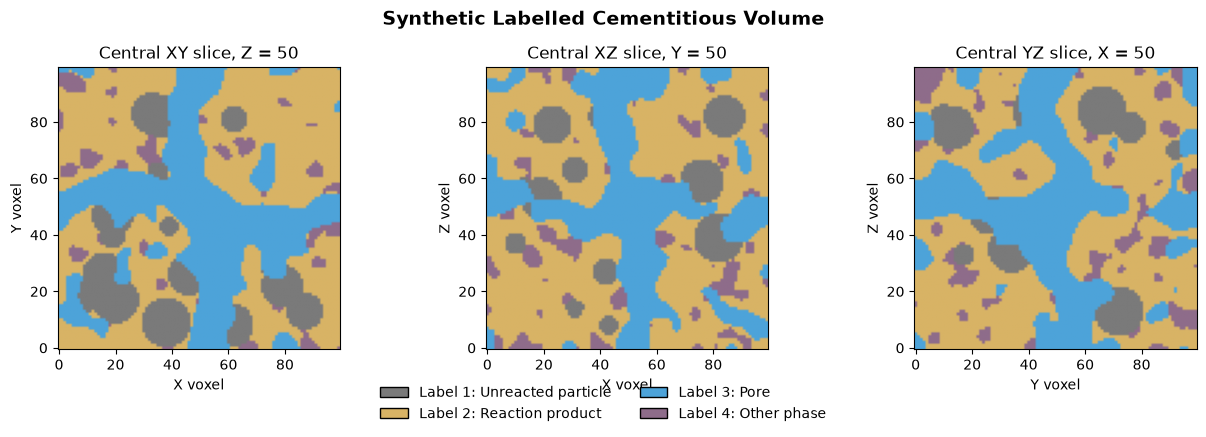

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


phase_colours = [
    "#7A7A7A",
    "#D8B365",
    "#4DA3D9",
    "#8E6C8A",
]

phase_cmap = ListedColormap(phase_colours)

phase_norm = BoundaryNorm(
    boundaries=[0.5, 1.5, 2.5, 3.5, 4.5],
    ncolors=phase_cmap.N,
)

z_centre = volume.shape[0] // 2
y_centre = volume.shape[1] // 2
x_centre = volume.shape[2] // 2

figure, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
)

axes[0].imshow(
    volume[z_centre, :, :],
    cmap=phase_cmap,
    norm=phase_norm,
    origin="lower",
)
axes[0].set_title(f"Central XY slice, Z = {z_centre}")
axes[0].set_xlabel("X voxel")
axes[0].set_ylabel("Y voxel")

axes[1].imshow(
    volume[:, y_centre, :],
    cmap=phase_cmap,
    norm=phase_norm,
    origin="lower",
)
axes[1].set_title(f"Central XZ slice, Y = {y_centre}")
axes[1].set_xlabel("X voxel")
axes[1].set_ylabel("Z voxel")

axes[2].imshow(
    volume[:, :, x_centre],
    cmap=phase_cmap,
    norm=phase_norm,
    origin="lower",
)
axes[2].set_title(f"Central YZ slice, X = {x_centre}")
axes[2].set_xlabel("Y voxel")
axes[2].set_ylabel("Z voxel")

legend_handles = [
    Patch(
        facecolor=phase_colours[index],
        edgecolor="black",
        label=f"Label {label}: {phase_name}",
    )
    for index, (label, phase_name)
    in enumerate(phase_definitions.items())
]

figure.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

figure.suptitle(
    "Synthetic Labelled Cementitious Volume",
    fontsize=14,
    fontweight="bold",
)

figure.tight_layout()
plt.show()

## 3. User-defined multi-phase fraction analysis

The phase-fraction module calculates voxel counts, volume fractions, and physical phase volumes for the user-defined integer labels.

Only labels included in `phase_definitions` are included in the analysed volume.

In [7]:
phase_fraction_results = calculate_phase_fractions(
    volume=volume,
    phases=phase_definitions,
    voxel_size_um=voxel_size_um,
)

phase_fraction_results

,label,phase_name,voxel_count,volume_fraction,volume_fraction_percent,physical_volume_um3,physical_volume_mm3
0,1,Unreacted particle,120000,0.12,12.0,41160.0,0.000041
1,2,Reaction product,650000,0.65,65.0,222950.0,0.000223
2,3,Pore,150000,0.15,15.0,51450.0,0.000051
3,4,Other phase,80000,0.08,8.0,27440.0,0.000027


In [8]:
print("Result type:", type(phase_fraction_results))
print("Columns:", phase_fraction_results.columns.tolist())

display(phase_fraction_results)

Result type: <class 'pandas.core.frame.DataFrame'>
Columns: ['label', 'phase_name', 'voxel_count', 'volume_fraction', 'volume_fraction_percent', 'physical_volume_um3', 'physical_volume_mm3']


,label,phase_name,voxel_count,volume_fraction,volume_fraction_percent,physical_volume_um3,physical_volume_mm3
0,1,Unreacted particle,120000,0.12,12.0,41160.0,0.000041
1,2,Reaction product,650000,0.65,65.0,222950.0,0.000223
2,3,Pore,150000,0.15,15.0,51450.0,0.000051
3,4,Other phase,80000,0.08,8.0,27440.0,0.000027


## 4. Isolated, accessible, and directional connectivity analysis

Connectivity is evaluated using strict face-connected 6-connectivity.

- Face-connected voxels are considered connected.
- Edge-only connections are excluded.
- Corner-only connections are excluded.

A directionally through-connected component must touch both opposing boundary faces in the selected physical direction.

In [9]:
connectivity_results = analyse_connectivity(
    volume=volume,
    phase_label=analysis_label,
)

print("Top-level result keys:")
print(connectivity_results.keys())

print("\nAvailable mask keys:")
print(connectivity_results["masks"].keys())

Top-level result keys:
dict_keys(['summary', 'masks', 'labelled_components'])

Available mask keys:
dict_keys(['selected', 'boundary_accessible', 'boundary_accessible_non_through', 'isolated', 'through_connected_X', 'through_connected_Y', 'through_connected_Z', 'through_connected_any_direction'])


In [10]:
directional_connectivity_rows = []

total_selected_voxels = int(
    np.count_nonzero(volume == analysis_label)
)

directional_mask_names = {
    "X": "through_connected_X",
    "Y": "through_connected_Y",
    "Z": "through_connected_Z",
}

for direction, mask_name in directional_mask_names.items():
    connected_mask = np.asarray(
        connectivity_results["masks"][mask_name],
        dtype=bool,
    )

    connected_voxels = int(
        np.count_nonzero(connected_mask)
    )

    connectivity_percent = (
        100.0 * connected_voxels / total_selected_voxels
    )

    directional_connectivity_rows.append(
        {
            "Direction": direction,
            "Selected phase voxels": total_selected_voxels,
            "Through-connected voxels": connected_voxels,
            "Directional connectivity (%)": connectivity_percent,
        }
    )

directional_connectivity_table = pd.DataFrame(
    directional_connectivity_rows
)

directional_connectivity_table

,Direction,Selected phase voxels,Through-connected voxels,Directional connectivity (%)
0,X,150000,88757,59.171333
1,Y,150000,88757,59.171333
2,Z,150000,88757,59.171333


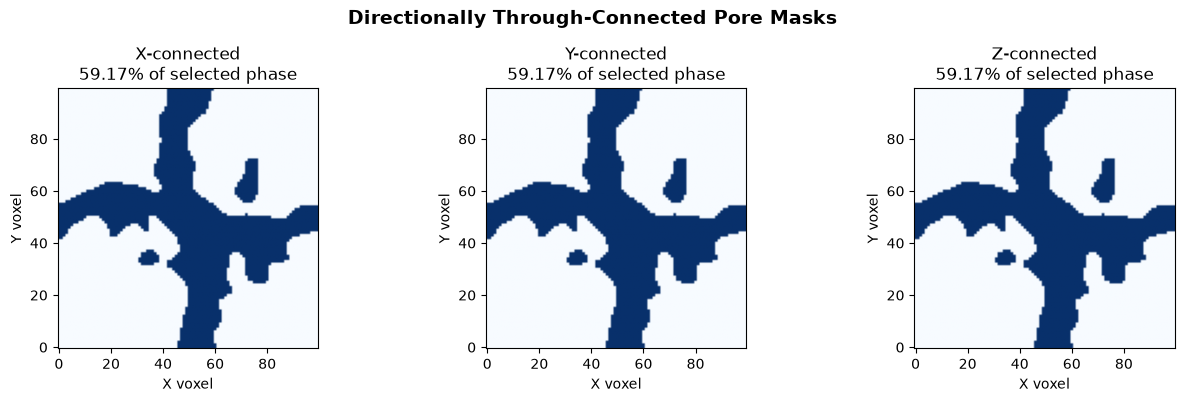

In [11]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
)

for axis, direction in zip(
    axes,
    analysis_directions,
):
    mask_name = directional_mask_names[direction]

    connected_mask = np.asarray(
        connectivity_results["masks"][mask_name],
        dtype=bool,
    )

    axis.imshow(
        connected_mask[z_centre, :, :],
        cmap="Blues",
        origin="lower",
        vmin=0,
        vmax=1,
    )

    connected_percent = directional_connectivity_table.loc[
        directional_connectivity_table["Direction"] == direction,
        "Directional connectivity (%)",
    ].iloc[0]

    axis.set_title(
        f"{direction}-connected\n"
        f"{connected_percent:.2f}% of selected phase"
    )
    axis.set_xlabel("X voxel")
    axis.set_ylabel("Y voxel")

figure.suptitle(
    "Directionally Through-Connected Pore Masks",
    fontsize=14,
    fontweight="bold",
)

figure.tight_layout()
plt.show()

## 5. Local-thickness-based pore-size analysis

The selected phase is analysed using a local-thickness method. Each selected-phase voxel is assigned a physical local diameter corresponding to the largest inscribed sphere containing that voxel.

The resulting distribution is volume weighted because every selected-phase voxel contributes one local-diameter value.

In [12]:
pore_size_results = calculate_pore_size_distribution(
    volume=volume,
    phase_label=analysis_label,
    voxel_size_um=voxel_size_um,
    number_of_bins=30,
    method="dt",
    sizes=25,
)

print("Pore-size result keys:")
print(pore_size_results.keys())

Pore-size result keys:
dict_keys(['summary', 'selected_mask', 'local_diameter_um', 'size_classes', 'distribution', 'cumulative'])


In [13]:
def describe_result_mapping(result_mapping):
    for key, value in result_mapping.items():
        if isinstance(value, np.ndarray):
            print(
                f"{key}: ndarray, "
                f"shape={value.shape}, "
                f"dtype={value.dtype}"
            )

        elif isinstance(value, pd.DataFrame):
            print(
                f"{key}: DataFrame, "
                f"shape={value.shape}, "
                f"columns={value.columns.tolist()}"
            )

        elif isinstance(value, pd.Series):
            print(
                f"{key}: Series, "
                f"shape={value.shape}"
            )

        elif isinstance(value, dict):
            print(
                f"{key}: dict, "
                f"keys={list(value.keys())}"
            )

        else:
            value_text = repr(value)

            if len(value_text) > 150:
                value_text = value_text[:147] + "..."

            print(
                f"{key}: "
                f"{type(value).__name__}, "
                f"value={value_text}"
            )


describe_result_mapping(pore_size_results)

summary: dict, keys=['phase_label', 'volume_shape_ZYX', 'voxel_size_um', 'total_volume_voxel_count', 'selected_voxel_count', 'selected_phase_fraction', 'selected_phase_fraction_percent', 'selected_physical_volume_um3', 'minimum_local_diameter_um', 'median_local_diameter_um', 'mean_local_diameter_um', 'maximum_local_diameter_um', 'number_of_bins', 'local_thickness_method', 'local_thickness_sizes']
selected_mask: ndarray, shape=(100, 100, 100), dtype=bool
local_diameter_um: ndarray, shape=(100, 100, 100), dtype=float32
size_classes: DataFrame, shape=(3, 8), columns=['class_name', 'diameter_range_um', 'voxel_count', 'fraction_of_selected_phase', 'fraction_of_selected_phase_percent', 'porosity_contribution_percent', 'physical_volume_um3', 'physical_volume_mm3']
distribution: DataFrame, shape=(30, 8), columns=['bin_lower_diameter_um', 'bin_upper_diameter_um', 'bin_centre_diameter_um', 'log10_bin_centre', 'voxel_count', 'fraction_of_selected_phase', 'porosity_contribution_percent', 'differen

### Pore-size analysis summary

The summary reports the selected-phase fraction, physical phase volume, and descriptive statistics of the local pore diameter.

In [14]:
pore_size_summary_table = pd.DataFrame(
    [pore_size_results["summary"]]
)

display(pore_size_summary_table.T)

,0
phase_label,3
volume_shape_ZYX,"(100, 100, 100)"
voxel_size_um,0.7
total_volume_voxel_count,1000000
selected_voxel_count,150000
selected_phase_fraction,0.15
selected_phase_fraction_percent,15.0
selected_physical_volume_um3,51450.0
minimum_local_diameter_um,1.4
median_local_diameter_um,6.227145


In [15]:
pore_size_class_table = pore_size_results[
    "size_classes"
].copy()

display(pore_size_class_table)

,class_name,diameter_range_um,voxel_count,fraction_of_selected_phase,fraction_of_selected_phase_percent,porosity_contribution_percent,physical_volume_um3,physical_volume_mm3
0,Small capillary pores,<1,0,0.000000,0.000000,0.00,0.0,0.000000
1,Large capillary pores,1-10,134900,0.899333,89.933333,13.49,46270.7,0.000046
2,Macropores,>10,15100,0.100667,10.066667,1.51,5179.3,0.000005


In [16]:
pore_size_distribution_table = pore_size_results[
    "distribution"
].copy()

pore_size_cumulative_table = pore_size_results[
    "cumulative"
].copy()

display(pore_size_distribution_table.head())
display(pore_size_cumulative_table.head())

,bin_lower_diameter_um,bin_upper_diameter_um,bin_centre_diameter_um,log10_bin_centre,voxel_count,fraction_of_selected_phase,porosity_contribution_percent,differential_porosity_percent_per_log10D
0,1.400000,1.508468,1.453222,0.162332,1109,0.007393,0.1109,3.421990
1,1.508468,1.625340,1.565814,0.194740,0,0.000000,0.0000,0.000000
2,1.625340,1.751266,1.687128,0.227148,0,0.000000,0.0000,0.000000
3,1.751266,1.886949,1.817842,0.259556,1787,0.011913,0.1787,5.514063
4,1.886949,2.033145,1.958683,0.291964,0,0.000000,0.0000,0.000000


,diameter_threshold_um,cumulative_voxel_count_D_greater_equal,cumulative_fraction_of_selected_phase,cumulative_pore_volume_percent_of_sample
0,1.453222,150000,1.000000,15.0000
1,1.565814,148891,0.992607,14.8891
2,1.687128,148891,0.992607,14.8891
3,1.817842,148891,0.992607,14.8891
4,1.958683,147104,0.980693,14.7104


### Local-diameter map

The local-diameter map assigns a physical diameter in micrometres to every voxel belonging to the selected phase. Background voxels are excluded from the visualisation.

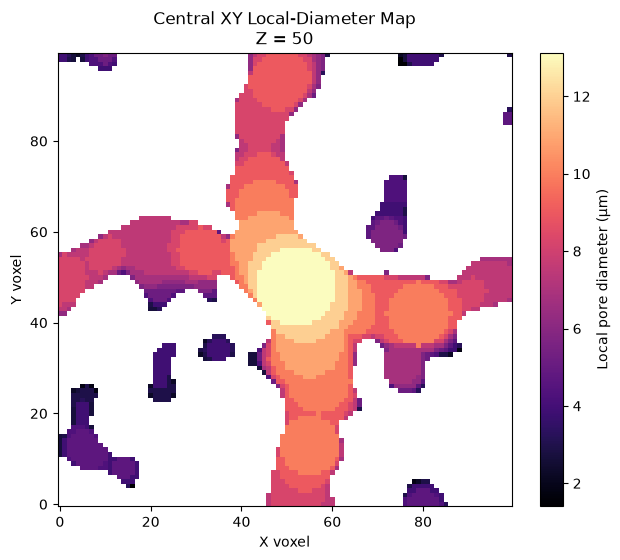

In [17]:
local_diameter_um = pore_size_results[
    "local_diameter_um"
]

selected_phase_mask = pore_size_results[
    "selected_mask"
]

central_diameter_slice = np.ma.masked_where(
    ~selected_phase_mask[z_centre, :, :],
    local_diameter_um[z_centre, :, :],
)

figure_local_diameter, axis = plt.subplots(
    figsize=(6.5, 5.5)
)

image = axis.imshow(
    central_diameter_slice,
    cmap="magma",
    origin="lower",
)

colour_bar = figure_local_diameter.colorbar(
    image,
    ax=axis,
)

colour_bar.set_label(
    "Local pore diameter (µm)"
)

axis.set_title(
    f"Central XY Local-Diameter Map\n"
    f"Z = {z_centre}"
)

axis.set_xlabel("X voxel")
axis.set_ylabel("Y voxel")

figure_local_diameter.tight_layout()
plt.show()

### Pore-size distributions

The analysis is reported using three complementary representations:

1. Porosity contribution by pore-size class
2. Differential pore-size distribution on a logarithmic diameter axis
3. Cumulative pore volume for local diameter greater than or equal to the threshold diameter

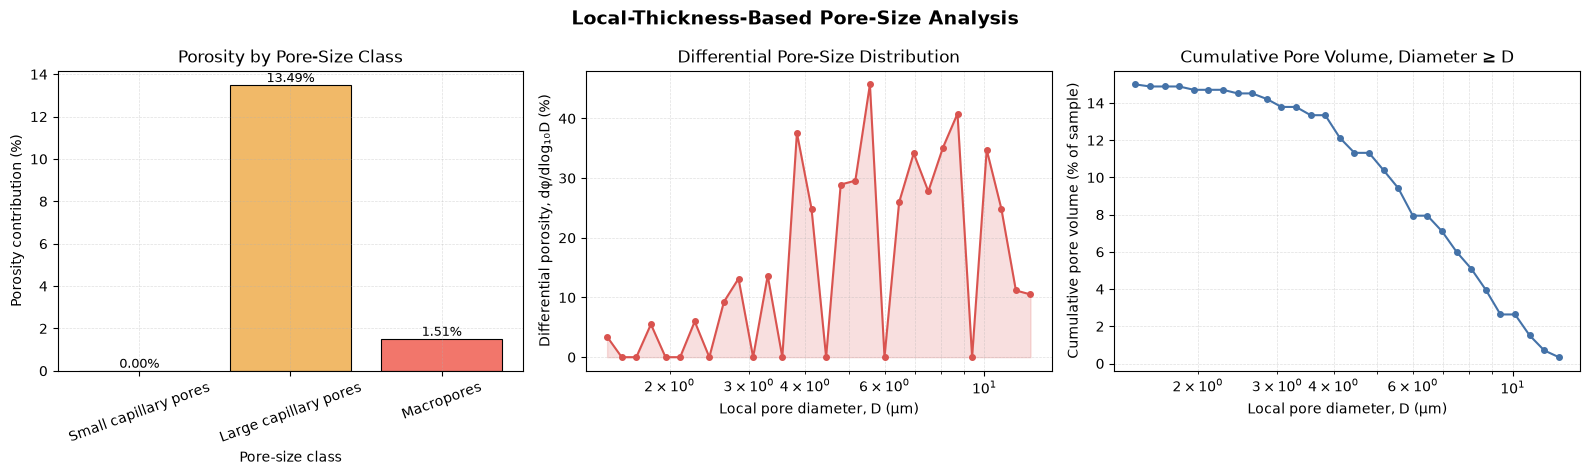

In [18]:
size_classes = pore_size_results[
    "size_classes"
].copy()

distribution = pore_size_results[
    "distribution"
].copy()

cumulative = pore_size_results[
    "cumulative"
].copy()


figure_pore_size, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
)


# -------------------------------------------------------------------------
# Plot 1: pore-size classes
# -------------------------------------------------------------------------

class_colours = [
    "#74C5B8",
    "#F1B968",
    "#F2766B",
]

bars = axes[0].bar(
    size_classes["class_name"],
    size_classes["porosity_contribution_percent"],
    color=class_colours[:len(size_classes)],
    edgecolor="black",
    linewidth=0.8,
)

axes[0].set_title(
    "Porosity by Pore-Size Class"
)

axes[0].set_ylabel(
    "Porosity contribution (%)"
)

axes[0].set_xlabel(
    "Pore-size class"
)

axes[0].tick_params(
    axis="x",
    rotation=20,
)

for bar, value in zip(
    bars,
    size_classes["porosity_contribution_percent"],
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )


# -------------------------------------------------------------------------
# Plot 2: differential pore-size distribution
# -------------------------------------------------------------------------

valid_distribution = distribution[
    distribution["bin_centre_diameter_um"] > 0
].copy()

axes[1].plot(
    valid_distribution["bin_centre_diameter_um"],
    valid_distribution[
        "differential_porosity_percent_per_log10D"
    ],
    color="#D9534F",
    marker="o",
    markersize=4,
    linewidth=1.5,
)

axes[1].fill_between(
    valid_distribution["bin_centre_diameter_um"],
    valid_distribution[
        "differential_porosity_percent_per_log10D"
    ],
    color="#D9534F",
    alpha=0.18,
)

axes[1].set_xscale("log")

axes[1].set_title(
    "Differential Pore-Size Distribution"
)

axes[1].set_xlabel(
    "Local pore diameter, D (µm)"
)

axes[1].set_ylabel(
    "Differential porosity, dφ/dlog₁₀D (%)"
)


# -------------------------------------------------------------------------
# Plot 3: cumulative pore volume
# -------------------------------------------------------------------------

valid_cumulative = cumulative[
    cumulative["diameter_threshold_um"] > 0
].copy()

axes[2].plot(
    valid_cumulative["diameter_threshold_um"],
    valid_cumulative[
        "cumulative_pore_volume_percent_of_sample"
    ],
    color="#4472A8",
    marker="o",
    markersize=4,
    linewidth=1.5,
)

axes[2].set_xscale("log")

axes[2].set_title(
    "Cumulative Pore Volume, Diameter ≥ D"
)

axes[2].set_xlabel(
    "Local pore diameter, D (µm)"
)

axes[2].set_ylabel(
    "Cumulative pore volume (% of sample)"
)


for axis in axes:
    axis.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.5,
        alpha=0.4,
    )


figure_pore_size.suptitle(
    "Local-Thickness-Based Pore-Size Analysis",
    fontsize=14,
    fontweight="bold",
)

figure_pore_size.tight_layout()
plt.show()

### Export pore-size results

Numerical tables, the selected-phase mask, the local-diameter volume, metadata, and the summary figure are export

In [19]:
pore_size_export_paths = export_analysis_bundle(
    input_file=file_path,
    analysis_name="pore_size",
    tables={
        "Summary": pore_size_summary_table,
        "Pore Size Classes": size_classes,
        "Distribution": distribution,
        "Cumulative": cumulative,
    },
    masks={
        "selected_phase_mask": selected_phase_mask,
    },
    scalar_volumes={
        "local_diameter_um": local_diameter_um,
    },
    metadata=pore_size_results["summary"],
    figure=figure_pore_size,
)

pore_size_export_paths

{'output_directory': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results'),
 'binary_masks': {'selected_phase_mask': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_pore_size_selected_phase_mask.tif')},
 'scalar_volumes': {'local_diameter_um': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_pore_size_local_diameter_um.tif')},
 'excel': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_pore_size_results.xlsx'),
 'metadata_json': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_pore_size_metadata.json'),
 'figure': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phas

In [20]:
pore_size_output_directory = pore_size_export_paths[
    "output_directory"
]

print(
    "Output directory:",
    pore_size_output_directory,
)

for output_file in sorted(
    pore_size_output_directory.iterdir()
):
    if "pore_size" in output_file.name:
        print(output_file.name)

Output directory: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results
synthetic_labelled_cement_4phase_100_pore_size_local_diameter_um.tif
synthetic_labelled_cement_4phase_100_pore_size_metadata.json
synthetic_labelled_cement_4phase_100_pore_size_results.xlsx
synthetic_labelled_cement_4phase_100_pore_size_selected_phase_mask.tif
synthetic_labelled_cement_4phase_100_pore_size_summary.png


## 6. Directional finite-difference diffusion analysis

Finite-difference diffusion is solved only within the directionally through-connected region of the selected phase.

The X direction is calculated first as an integration test. The full X-, Y-, and Z-directional analysis is performed only after the X-direction calculation succeeds.

In [21]:
diffusion_x_results = calculate_directional_diffusion(
    volume=volume,
    phase_label=analysis_label,
    directions=("X",),
    solver=None,
    solver_tolerance=1e-10,
    maximum_iterations=5000,
)

print("Diffusion result keys:")
print(diffusion_x_results.keys())

Diffusion result keys:
dict_keys(['phase_label', 'connectivity_summary', 'direction_results', 'summary', 'concentration_fields'])


In [22]:
describe_result_mapping(
    diffusion_x_results
)

phase_label: int, value=3
connectivity_summary: dict, keys=['phase_label', 'selected_voxel_count', 'connected_component_count', 'boundary_accessible_component_count', 'boundary_accessible_voxel_count', 'isolated_voxel_count', 'X_connected_component_count', 'Y_connected_component_count', 'Z_connected_component_count', 'X_connected_voxel_count', 'Y_connected_voxel_count', 'Z_connected_voxel_count', 'any_direction_connected_voxel_count', 'boundary_accessible_fraction', 'isolated_fraction', 'X_connectivity', 'Y_connectivity', 'Z_connectivity', 'any_direction_connectivity']
direction_results: dict, keys=['X']
summary: DataFrame, shape=(1, 11), columns=['direction', 'axis', 'status', 'connected_voxel_count', 'directional_connectivity', 'original_porosity', 'effective_porosity', 'formation_factor', 'relative_effective_diffusivity', 'diffusion_tortuosity', 'run_time_seconds']
concentration_fields: dict, keys=['X']


In [23]:
for key, value in diffusion_x_results.items():
    if isinstance(value, dict):
        print()
        print(f"Nested result: {key}")
        describe_result_mapping(value)


Nested result: connectivity_summary
phase_label: int, value=3
selected_voxel_count: int, value=150000
connected_component_count: int, value=110
boundary_accessible_component_count: int, value=64
boundary_accessible_voxel_count: int, value=138498
isolated_voxel_count: int, value=11502
X_connected_component_count: int, value=1
Y_connected_component_count: int, value=1
Z_connected_component_count: int, value=1
X_connected_voxel_count: int, value=88757
Y_connected_voxel_count: int, value=88757
Z_connected_voxel_count: int, value=88757
any_direction_connected_voxel_count: int, value=88757
boundary_accessible_fraction: float, value=0.92332
isolated_fraction: float, value=0.07668
X_connectivity: float, value=0.5917133333333333
Y_connectivity: float, value=0.5917133333333333
Z_connectivity: float, value=0.5917133333333333
any_direction_connectivity: float, value=0.5917133333333333

Nested result: direction_results
X: dict, keys=['status', 'direction', 'axis', 'connected_voxel_count', 'origina

In [24]:
diffusion_x_results["summary"]

,direction,axis,status,connected_voxel_count,directional_connectivity,original_porosity,effective_porosity,formation_factor,relative_effective_diffusivity,diffusion_tortuosity,run_time_seconds
0,X,2,calculated,88757,0.591713,0.088757,0.088757,54.21952,0.018444,4.812362,2.599861


In [25]:
diffusion_xyz_results = calculate_directional_diffusion(
    volume=volume,
    phase_label=analysis_label,
    directions=("X", "Y", "Z"),
    solver=None,
    solver_tolerance=1e-10,
    maximum_iterations=5000,
)

diffusion_xyz_summary = diffusion_xyz_results["summary"]

diffusion_xyz_summary

,direction,axis,status,connected_voxel_count,directional_connectivity,original_porosity,effective_porosity,formation_factor,relative_effective_diffusivity,diffusion_tortuosity,run_time_seconds
0,X,2,calculated,88757,0.591713,0.088757,0.088757,54.21952,0.018444,4.812362,1.812422
1,Y,1,calculated,88757,0.591713,0.088757,0.088757,50.62048,0.019755,4.492922,1.478072
2,Z,0,calculated,88757,0.591713,0.088757,0.088757,46.27917,0.021608,4.107600,1.583021


In [26]:
display_columns = [
    "direction",
    "status",
    "directional_connectivity",
    "effective_porosity",
    "formation_factor",
    "relative_effective_diffusivity",
    "diffusion_tortuosity",
    "run_time_seconds",
]

diffusion_xyz_summary[display_columns]

,direction,status,directional_connectivity,effective_porosity,formation_factor,relative_effective_diffusivity,diffusion_tortuosity,run_time_seconds
0,X,calculated,0.591713,0.088757,54.21952,0.018444,4.812362,1.812422
1,Y,calculated,0.591713,0.088757,50.62048,0.019755,4.492922,1.478072
2,Z,calculated,0.591713,0.088757,46.27917,0.021608,4.107600,1.583021


In [27]:
successful_statuses = {
    "calculated",
    "solved",
    "completed",
    "success",
}

normalised_status = (
    diffusion_xyz_summary["status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

successful_directions = normalised_status.isin(
    successful_statuses
)

print(
    "All directional calculations completed successfully:",
    successful_directions.all(),
)

print("\nDirectional status:")
print(
    diffusion_xyz_summary[
        ["direction", "status"]
    ].to_string(index=False)
)

All directional calculations completed successfully: True

Directional status:
direction     status
        X calculated
        Y calculated
        Z calculated


In [28]:
for direction, concentration_field in (
    diffusion_xyz_results["concentration_fields"].items()
):
    print(
        f"{direction}: "
        f"shape={concentration_field.shape}, "
        f"dtype={concentration_field.dtype}, "
        f"minimum={np.nanmin(concentration_field):.6f}, "
        f"maximum={np.nanmax(concentration_field):.6f}"
    )

X: shape=(100, 100, 100), dtype=float32, minimum=0.000000, maximum=1.000000
Y: shape=(100, 100, 100), dtype=float32, minimum=0.000000, maximum=1.000000
Z: shape=(100, 100, 100), dtype=float32, minimum=0.000000, maximum=1.000000


### Directional diffusion results

The finite-difference diffusion analysis is performed independently along the
X, Y, and Z directions using only the corresponding directionally
through-connected pore space.

The analysis reports:

- Directional diffusion tortuosity
- Formation factor
- Relative effective diffusivity
- Effective porosity
- Directional concentration fields

The concentration fields are stored in NumPy array order `(Z, Y, X)`.
Regions outside the directionally connected pore space are excluded from the
diffusion calculation.

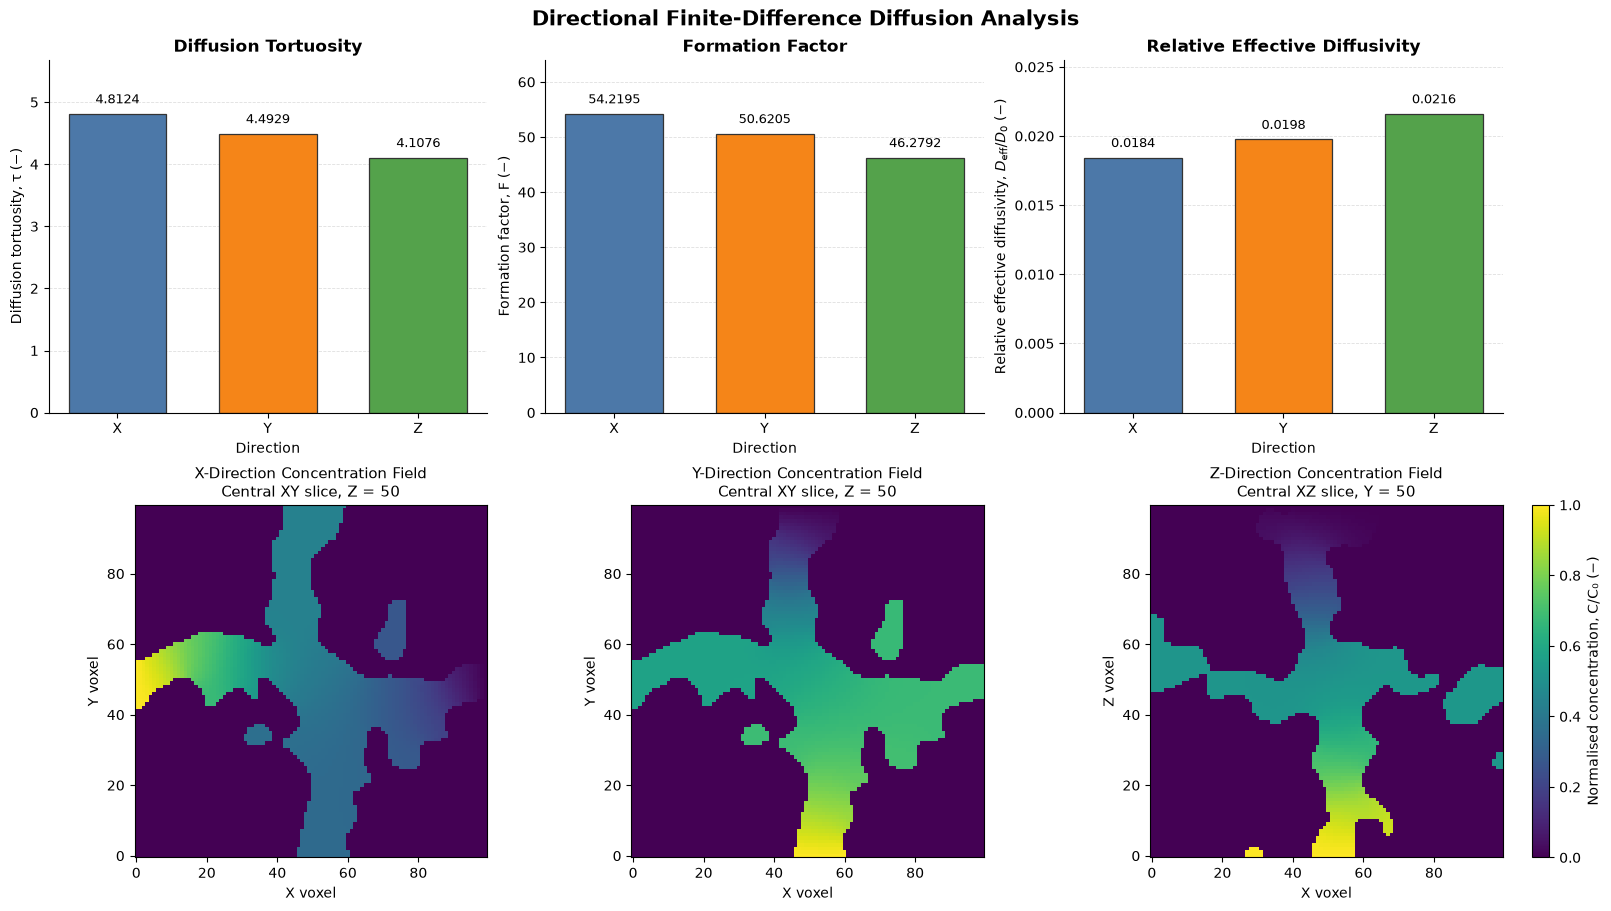

In [29]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Prepare directional diffusion results
# ============================================================

diffusion_plot_summary = (
    diffusion_xyz_results["summary"]
    .copy()
    .sort_values("direction")
    .reset_index(drop=True)
)

directions = diffusion_plot_summary[
    "direction"
].astype(str).to_numpy()

formation_factor = diffusion_plot_summary[
    "formation_factor"
].to_numpy(dtype=float)

relative_diffusivity = diffusion_plot_summary[
    "relative_effective_diffusivity"
].to_numpy(dtype=float)

diffusion_tortuosity = diffusion_plot_summary[
    "diffusion_tortuosity"
].to_numpy(dtype=float)

direction_colours = {
    "X": "#4C78A8",
    "Y": "#F58518",
    "Z": "#54A24B",
}

bar_colours = [
    direction_colours.get(direction, "#808080")
    for direction in directions
]


# ============================================================
# Create combined figure
# ============================================================

figure_diffusion, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9),
    constrained_layout=True,
)


# ============================================================
# Top row: directional numerical results
# ============================================================

top_row_data = [
    (
        diffusion_tortuosity,
        "Diffusion Tortuosity",
        "Diffusion tortuosity, τ (−)",
    ),
    (
        formation_factor,
        "Formation Factor",
        "Formation factor, F (−)",
    ),
    (
        relative_diffusivity,
        "Relative Effective Diffusivity",
        r"Relative effective diffusivity, $D_\mathrm{eff}/D_0$ (−)",
    ),
]


for axis, (values, title, ylabel) in zip(
    axes[0],
    top_row_data,
):
    bars = axis.bar(
        directions,
        values,
        color=bar_colours,
        edgecolor="#333333",
        linewidth=0.9,
        width=0.65,
    )

    axis.set_title(
        title,
        fontsize=12,
        fontweight="bold",
    )

    axis.set_xlabel("Direction")
    axis.set_ylabel(ylabel)

    axis.grid(
        True,
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.4,
    )

    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    maximum_value = float(np.nanmax(values))
    axis.set_ylim(
        0,
        maximum_value * 1.18,
    )

    for bar, value in zip(bars, values):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + maximum_value * 0.025,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


# ============================================================
# Bottom row: directional concentration fields
# ============================================================

concentration_fields = (
    diffusion_xyz_results["concentration_fields"]
)

z_centre = volume.shape[0] // 2
y_centre = volume.shape[1] // 2

concentration_images = []


# X-direction: central XY slice
field_x = np.asarray(
    concentration_fields["X"],
    dtype=float,
)

field_x_slice = np.ma.masked_invalid(
    field_x[z_centre, :, :]
)

image_x = axes[1, 0].imshow(
    field_x_slice,
    cmap="viridis",
    origin="lower",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest",
)

concentration_images.append(image_x)

axes[1, 0].set_title(
    f"X-Direction Concentration Field\nCentral XY slice, Z = {z_centre}",
    fontsize=11,
)

axes[1, 0].set_xlabel("X voxel")
axes[1, 0].set_ylabel("Y voxel")


# Y-direction: central XY slice
field_y = np.asarray(
    concentration_fields["Y"],
    dtype=float,
)

field_y_slice = np.ma.masked_invalid(
    field_y[z_centre, :, :]
)

image_y = axes[1, 1].imshow(
    field_y_slice,
    cmap="viridis",
    origin="lower",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest",
)

concentration_images.append(image_y)

axes[1, 1].set_title(
    f"Y-Direction Concentration Field\nCentral XY slice, Z = {z_centre}",
    fontsize=11,
)

axes[1, 1].set_xlabel("X voxel")
axes[1, 1].set_ylabel("Y voxel")


# Z-direction: central XZ slice
field_z = np.asarray(
    concentration_fields["Z"],
    dtype=float,
)

field_z_slice = np.ma.masked_invalid(
    field_z[:, y_centre, :]
)

image_z = axes[1, 2].imshow(
    field_z_slice,
    cmap="viridis",
    origin="lower",
    vmin=0.0,
    vmax=1.0,
    interpolation="nearest",
)

concentration_images.append(image_z)

axes[1, 2].set_title(
    f"Z-Direction Concentration Field\nCentral XZ slice, Y = {y_centre}",
    fontsize=11,
)

axes[1, 2].set_xlabel("X voxel")
axes[1, 2].set_ylabel("Z voxel")


# Shared concentration colour bar
colour_bar = figure_diffusion.colorbar(
    concentration_images[0],
    ax=axes[1, :].tolist(),
    orientation="vertical",
    fraction=0.025,
    pad=0.02,
)

colour_bar.set_label(
    "Normalised concentration, C/C₀ (−)"
)


# ============================================================
# Figure title
# ============================================================

figure_diffusion.suptitle(
    "Directional Finite-Difference Diffusion Analysis",
    fontsize=15,
    fontweight="bold",
)

plt.show()

In [30]:
import pandas as pd


diffusion_connectivity_table = pd.DataFrame(
    [
        diffusion_xyz_results[
            "connectivity_summary"
        ]
    ]
)

diffusion_metadata = {
    "analysis": "Directional finite-difference diffusion",
    "phase_label": int(analysis_label),
    "phase_name": str(analysis_phase_name),
    "voxel_size_um": float(voxel_size_um),
    "array_order": "Z, Y, X",
    "directions": ["X", "Y", "Z"],
    "connectivity_definition": "6-connectivity",
    "solver_tolerance": 1e-10,
    "maximum_iterations": 5000,
    "concentration_inlet": 1.0,
    "concentration_outlet": 0.0,
}

display(diffusion_xyz_summary)
display(diffusion_connectivity_table)

,direction,axis,status,connected_voxel_count,directional_connectivity,original_porosity,effective_porosity,formation_factor,relative_effective_diffusivity,diffusion_tortuosity,run_time_seconds
0,X,2,calculated,88757,0.591713,0.088757,0.088757,54.21952,0.018444,4.812362,1.812422
1,Y,1,calculated,88757,0.591713,0.088757,0.088757,50.62048,0.019755,4.492922,1.478072
2,Z,0,calculated,88757,0.591713,0.088757,0.088757,46.27917,0.021608,4.107600,1.583021


,phase_label,selected_voxel_count,connected_component_count,boundary_accessible_component_count,boundary_accessible_voxel_count,isolated_voxel_count,X_connected_component_count,Y_connected_component_count,Z_connected_component_count,X_connected_voxel_count,Y_connected_voxel_count,Z_connected_voxel_count,any_direction_connected_voxel_count,boundary_accessible_fraction,isolated_fraction,X_connectivity,Y_connectivity,Z_connectivity,any_direction_connectivity
0,3,150000,110,64,138498,11502,1,1,1,88757,88757,88757,88757,0.92332,0.07668,0.591713,0.591713,0.591713,0.591713


In [31]:
from cemct.export import export_analysis_bundle


diffusion_exported_paths = export_analysis_bundle(
    input_file=file_path,
    analysis_name="directional_diffusion",
    tables={
        "Diffusion Summary": diffusion_xyz_summary,
        "Connectivity Summary": diffusion_connectivity_table,
    },
    scalar_volumes={
        "concentration_field_X": (
            concentration_fields["X"]
        ),
        "concentration_field_Y": (
            concentration_fields["Y"]
        ),
        "concentration_field_Z": (
            concentration_fields["Z"]
        ),
    },
    metadata=diffusion_metadata,
    figure=figure_diffusion,
)

diffusion_exported_paths

{'output_directory': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results'),
 'binary_masks': {},
 'scalar_volumes': {'concentration_field_X': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_directional_diffusion_concentration_field_X.tif'),
  'concentration_field_Y': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_directional_diffusion_concentration_field_Y.tif'),
  'concentration_field_Z': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_directional_diffusion_concentration_field_Z.tif')},
 'excel': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_directional_diffusion_results.xlsx'),
 'meta

In [32]:
from pathlib import Path


def print_exported_paths(
    exported_mapping,
    indentation=0,
):
    prefix = " " * indentation

    for key, value in exported_mapping.items():
        if isinstance(value, dict):
            print(f"{prefix}{key}:")
            print_exported_paths(
                value,
                indentation=indentation + 4,
            )
        else:
            path = Path(value)

            print(
                f"{prefix}{key}: "
                f"{path} "
                f"[exists={path.exists()}]"
            )


print_exported_paths(
    diffusion_exported_paths
)

output_directory: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results [exists=True]
binary_masks:
scalar_volumes:
    concentration_field_X: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_directional_diffusion_concentration_field_X.tif [exists=True]
    concentration_field_Y: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_directional_diffusion_concentration_field_Y.tif [exists=True]
    concentration_field_Z: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_directional_diffusion_concentration_field_Z.tif [exists=True]
excel: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_directional_diffusion_results.xlsx [exists=True]
metadata_json: C:\Users\zixia\Xs

## 7. Random-Walk-Based Transport Analysis

Random-walk simulation provides a particle-based method for characterising
transport through the connected pore space.

The analysis is performed only within the connected region of the
user-selected phase. Individual walkers move between face-connected voxels,
and their mean-squared displacement is evaluated as a function of the number
of random-walk steps.

This module provides a complementary transport analysis to the finite-
difference diffusion calculation. The finite-difference method solves a
steady-state concentration field, whereas the random-walk method tracks the
statistical displacement of particles through the connected pore geometry.

A reduced number of walkers and steps is used initially as an integration
test. Larger simulations can subsequently be performed for final quantitative
analysis.

In [33]:
random_walk_test_results = calculate_connected_random_walk(
    volume=volume,
    phase_label=analysis_label,
    connectivity_mode="any",
    number_of_steps=2000,
    number_of_walkers=1000,
    stride=10,
    same_start=False,
    number_of_processes=1,
    deterministic_seed=True,
    fit_start_fraction=0.1,
    fit_end_fraction=0.9,
    return_coordinates=False,
)

print("Random-walk calculation completed.")
print(
    "Result keys:",
    random_walk_test_results.keys(),
)

Random-walk calculation completed.
Result keys: dict_keys(['summary', 'transport_mask', 'msd', 'fit_results', 'connectivity_summary'])


In [34]:
describe_result_mapping(
    random_walk_test_results
)

summary: dict, keys=['accessible_voxel_count', 'accessible_fraction', 'number_of_steps', 'number_of_walkers', 'stride', 'saved_time_point_count', 'same_start', 'number_of_processes', 'deterministic_seed', 'fit_start_fraction', 'fit_end_fraction', 'mean_tortuosity', 'mean_msd_slope', 'mean_r_squared', 'X_tortuosity', 'Y_tortuosity', 'Z_tortuosity', 'X_msd_slope', 'Y_msd_slope', 'Z_msd_slope', 'X_r_squared', 'Y_r_squared', 'Z_r_squared', 'phase_label', 'connectivity_mode', 'connected_voxel_count', 'X_connectivity', 'Y_connectivity', 'Z_connectivity']
transport_mask: ndarray, shape=(100, 100, 100), dtype=bool
msd: DataFrame, shape=(200, 5), columns=['time_step', 'mean_square_displacement', 'scaled_axial_msd_X', 'scaled_axial_msd_Y', 'scaled_axial_msd_Z']
fit_results: dict, keys=['mean', 'X', 'Y', 'Z']
connectivity_summary: dict, keys=['phase_label', 'selected_voxel_count', 'connected_component_count', 'boundary_accessible_component_count', 'boundary_accessible_voxel_count', 'isolated_voxe

In [35]:
for key, value in random_walk_test_results.items():

    if isinstance(value, dict):
        print(f"\nNested result: {key}")
        describe_result_mapping(value)

    elif isinstance(value, np.ndarray):
        print(
            f"{key}: "
            f"shape={value.shape}, "
            f"dtype={value.dtype}"
        )

    elif isinstance(value, pd.DataFrame):
        print(
            f"{key}: "
            f"DataFrame shape={value.shape}, "
            f"columns={value.columns.tolist()}"
        )

    else:
        print(
            f"{key}: "
            f"type={type(value).__name__}, "
            f"value={value}"
        )


Nested result: summary
accessible_voxel_count: int, value=88757
accessible_fraction: float, value=0.088757
number_of_steps: int, value=2000
number_of_walkers: int, value=1000
stride: int, value=10
saved_time_point_count: int, value=200
same_start: bool, value=False
number_of_processes: int, value=1
deterministic_seed: bool, value=True
fit_start_fraction: float, value=0.1
fit_end_fraction: float, value=0.9
mean_tortuosity: float, value=2.458761280569691
mean_msd_slope: float, value=0.4067088610441684
mean_r_squared: float, value=0.9478148279462091
X_tortuosity: float, value=2.4406587062263694
Y_tortuosity: float, value=2.409515880432478
Z_tortuosity: float, value=2.5292124089057935
X_msd_slope: float, value=0.40972545544729294
Y_msd_slope: float, value=0.4150211285681639
Z_msd_slope: float, value=0.39537999911704824
X_r_squared: float, value=0.955713322135311
Y_r_squared: float, value=0.9623653812299309
Z_r_squared: float, value=0.9033609959491207
phase_label: int, value=3
connectivity

In [36]:
random_walk_results = random_walk_test_results

random_walk_summary = random_walk_results["summary"]
random_walk_msd = random_walk_results["msd"].copy()
random_walk_fit_results = random_walk_results["fit_results"]
random_walk_transport_mask = random_walk_results["transport_mask"]

print("Random-walk summary:")
for key, value in random_walk_summary.items():
    print(f"{key}: {value}")

display(random_walk_msd)

Random-walk summary:
accessible_voxel_count: 88757
accessible_fraction: 0.088757
number_of_steps: 2000
number_of_walkers: 1000
stride: 10
saved_time_point_count: 200
same_start: False
number_of_processes: 1
deterministic_seed: True
fit_start_fraction: 0.1
fit_end_fraction: 0.9
mean_tortuosity: 2.458761280569691
mean_msd_slope: 0.4067088610441684
mean_r_squared: 0.9478148279462091
X_tortuosity: 2.4406587062263694
Y_tortuosity: 2.409515880432478
Z_tortuosity: 2.5292124089057935
X_msd_slope: 0.40972545544729294
Y_msd_slope: 0.4150211285681639
Z_msd_slope: 0.39537999911704824
X_r_squared: 0.955713322135311
Y_r_squared: 0.9623653812299309
Z_r_squared: 0.9033609959491207
phase_label: 3
connectivity_mode: ANY
connected_voxel_count: 88757
X_connectivity: 0.5917133333333333
Y_connectivity: 0.5917133333333333
Z_connectivity: 0.5917133333333333


,time_step,mean_square_displacement,scaled_axial_msd_X,scaled_axial_msd_Y,scaled_axial_msd_Z
0,0.0,0.000,0.000,0.000,0.000
1,10.0,8.348,8.076,8.367,8.601
2,20.0,15.891,16.020,15.756,15.897
3,30.0,23.102,22.929,22.959,23.418
4,40.0,30.518,30.138,30.309,31.107
...,...,...,...,...,...
195,1950.0,719.597,729.780,760.707,668.304
196,1960.0,725.816,737.706,764.202,675.540
197,1970.0,723.401,734.331,759.726,676.146
198,1980.0,727.566,740.790,760.875,681.033


MSD columns: ['time_step', 'mean_square_displacement', 'scaled_axial_msd_X', 'scaled_axial_msd_Y', 'scaled_axial_msd_Z']


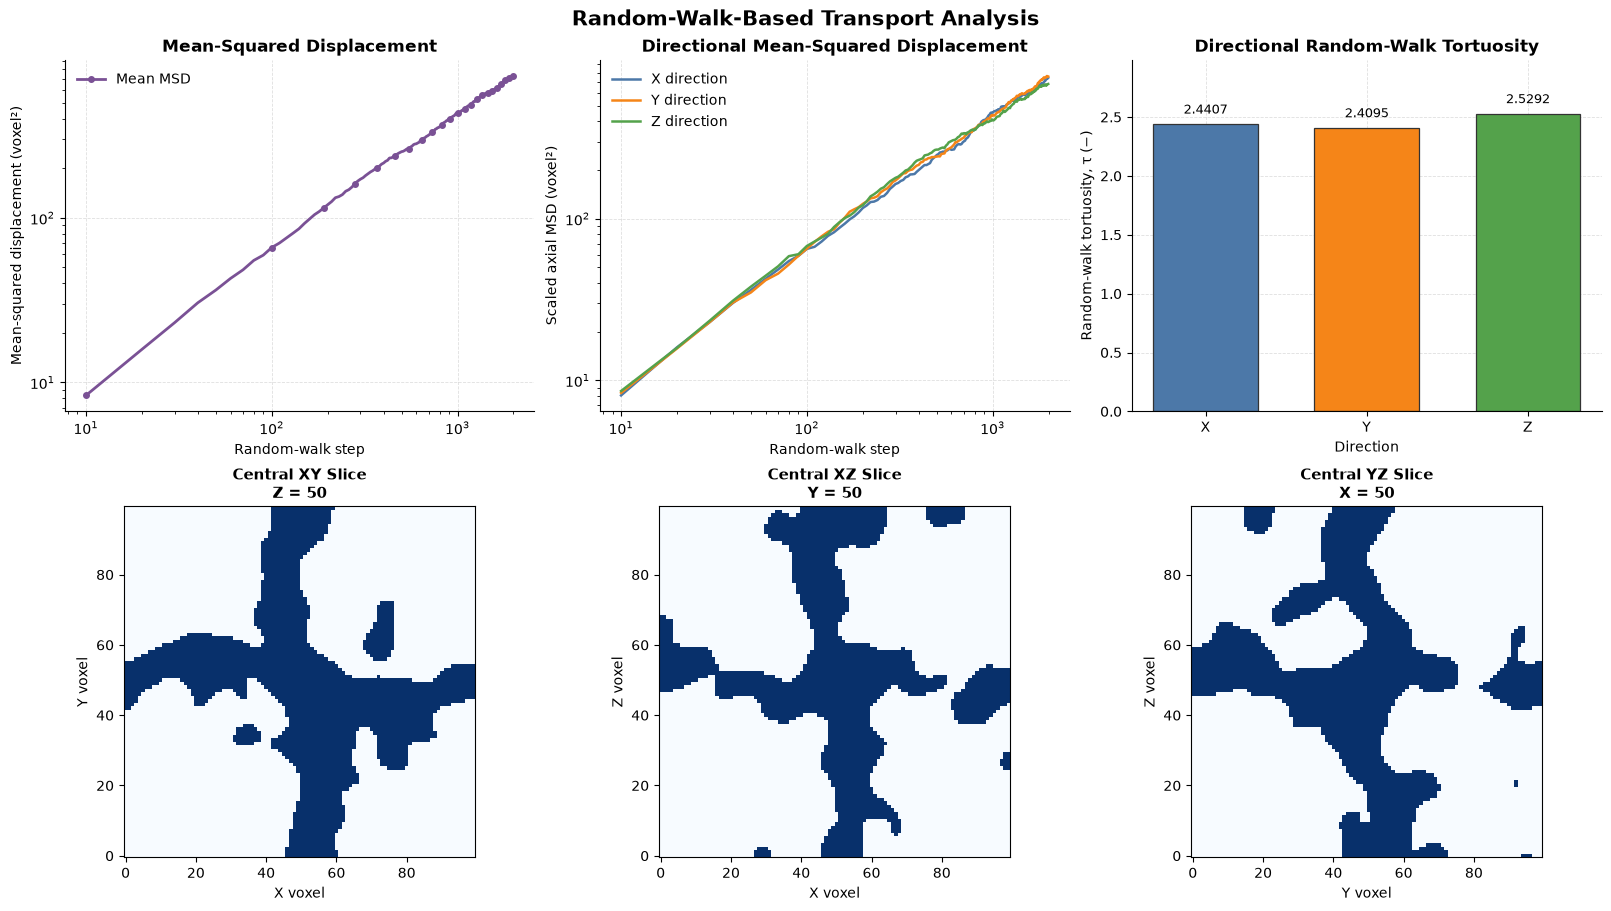

In [37]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Extract Random Walk results
# ============================================================

random_walk_results = random_walk_test_results

random_walk_summary = random_walk_results[
    "summary"
]

random_walk_msd = random_walk_results[
    "msd"
].copy()

random_walk_transport_mask = np.asarray(
    random_walk_results["transport_mask"],
    dtype=bool,
)


# ============================================================
# Check the available MSD columns
# ============================================================

print(
    "MSD columns:",
    random_walk_msd.columns.tolist(),
)


# ============================================================
# Extract MSD data
# ============================================================

time_steps = random_walk_msd[
    "time_step"
].to_numpy(dtype=float)

mean_msd = random_walk_msd[
    "mean_square_displacement"
].to_numpy(dtype=float)

# The direction suffixes are uppercase in CemCT
directional_msd = {
    "X": random_walk_msd[
        "scaled_axial_msd_X"
    ].to_numpy(dtype=float),

    "Y": random_walk_msd[
        "scaled_axial_msd_Y"
    ].to_numpy(dtype=float),

    "Z": random_walk_msd[
        "scaled_axial_msd_Z"
    ].to_numpy(dtype=float),
}


# ============================================================
# Extract directional tortuosity
# ============================================================

directional_tortuosity = {
    "X": float(
        random_walk_summary["X_tortuosity"]
    ),
    "Y": float(
        random_walk_summary["Y_tortuosity"]
    ),
    "Z": float(
        random_walk_summary["Z_tortuosity"]
    ),
}

direction_colours = {
    "X": "#4C78A8",
    "Y": "#F58518",
    "Z": "#54A24B",
}


# ============================================================
# Create combined figure
# ============================================================

figure_random_walk, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9),
    constrained_layout=True,
)


# ============================================================
# Panel 1: Mean-squared displacement
# ============================================================

mean_valid = (
    np.isfinite(time_steps)
    & np.isfinite(mean_msd)
    & (time_steps > 0)
    & (mean_msd > 0)
)

mean_valid_count = np.count_nonzero(
    mean_valid
)

mean_mark_every = max(
    1,
    mean_valid_count // 20,
)

axes[0, 0].loglog(
    time_steps[mean_valid],
    mean_msd[mean_valid],
    color="#7A5195",
    linewidth=2.0,
    marker="o",
    markersize=4,
    markevery=mean_mark_every,
    label="Mean MSD",
)

axes[0, 0].set_title(
    "Mean-Squared Displacement",
    fontsize=12,
    fontweight="bold",
)

axes[0, 0].set_xlabel(
    "Random-walk step"
)

axes[0, 0].set_ylabel(
    "Mean-squared displacement (voxel²)"
)

axes[0, 0].legend(
    frameon=False
)


# ============================================================
# Panel 2: Directional scaled axial MSD
# ============================================================

for direction in ("X", "Y", "Z"):

    directional_values = directional_msd[
        direction
    ]

    valid = (
        np.isfinite(time_steps)
        & np.isfinite(directional_values)
        & (time_steps > 0)
        & (directional_values > 0)
    )

    axes[0, 1].loglog(
        time_steps[valid],
        directional_values[valid],
        color=direction_colours[direction],
        linewidth=1.8,
        label=f"{direction} direction",
    )

axes[0, 1].set_title(
    "Directional Mean-Squared Displacement",
    fontsize=12,
    fontweight="bold",
)

axes[0, 1].set_xlabel(
    "Random-walk step"
)

axes[0, 1].set_ylabel(
    "Scaled axial MSD (voxel²)"
)

axes[0, 1].legend(
    frameon=False
)


# ============================================================
# Panel 3: Directional Random Walk tortuosity
# ============================================================

directions = np.array(
    ["X", "Y", "Z"]
)

tortuosity_values = np.array(
    [
        directional_tortuosity["X"],
        directional_tortuosity["Y"],
        directional_tortuosity["Z"],
    ],
    dtype=float,
)

bars = axes[0, 2].bar(
    directions,
    tortuosity_values,
    color=[
        direction_colours["X"],
        direction_colours["Y"],
        direction_colours["Z"],
    ],
    edgecolor="#333333",
    linewidth=0.9,
    width=0.65,
)

axes[0, 2].set_title(
    "Directional Random-Walk Tortuosity",
    fontsize=12,
    fontweight="bold",
)

axes[0, 2].set_xlabel(
    "Direction"
)

axes[0, 2].set_ylabel(
    "Random-walk tortuosity, τ (−)"
)

finite_tortuosity = tortuosity_values[
    np.isfinite(tortuosity_values)
]

if finite_tortuosity.size > 0:
    maximum_tortuosity = float(
        np.max(finite_tortuosity)
    )
else:
    maximum_tortuosity = 1.0

axes[0, 2].set_ylim(
    bottom=0,
    top=max(
        maximum_tortuosity * 1.18,
        1.0,
    ),
)

for bar, value in zip(
    bars,
    tortuosity_values,
):
    if np.isfinite(value):
        axes[0, 2].text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height()
            + maximum_tortuosity * 0.025,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


# ============================================================
# Prepare central transport-mask slices
# ============================================================

z_centre = (
    random_walk_transport_mask.shape[0] // 2
)

y_centre = (
    random_walk_transport_mask.shape[1] // 2
)

x_centre = (
    random_walk_transport_mask.shape[2] // 2
)

mask_slices = [
    (
        random_walk_transport_mask[
            z_centre,
            :,
            :,
        ],
        f"Central XY Slice\nZ = {z_centre}",
        "X voxel",
        "Y voxel",
    ),
    (
        random_walk_transport_mask[
            :,
            y_centre,
            :,
        ],
        f"Central XZ Slice\nY = {y_centre}",
        "X voxel",
        "Z voxel",
    ),
    (
        random_walk_transport_mask[
            :,
            :,
            x_centre,
        ],
        f"Central YZ Slice\nX = {x_centre}",
        "Y voxel",
        "Z voxel",
    ),
]


# ============================================================
# Bottom row: connected transport-mask slices
# ============================================================

for axis, (
    mask_slice,
    title,
    xlabel,
    ylabel,
) in zip(
    axes[1],
    mask_slices,
):
    axis.imshow(
        mask_slice,
        cmap="Blues",
        origin="lower",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    axis.set_title(
        title,
        fontsize=11,
        fontweight="bold",
    )

    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)

    axis.set_aspect("equal")


# ============================================================
# General formatting
# ============================================================

for axis in axes[0]:
    axis.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.4,
    )

    axis.set_axisbelow(True)

    axis.spines["top"].set_visible(
        False
    )

    axis.spines["right"].set_visible(
        False
    )


# ============================================================
# Main figure title
# ============================================================

figure_random_walk.suptitle(
    "Random-Walk-Based Transport Analysis",
    fontsize=15,
    fontweight="bold",
)

plt.show()

In [38]:
import pandas as pd


random_walk_summary_table = pd.DataFrame(
    [random_walk_summary]
)

random_walk_connectivity_table = pd.DataFrame(
    [
        random_walk_results[
            "connectivity_summary"
        ]
    ]
)

random_walk_fit_rows = []

for direction, fit_values in (
    random_walk_fit_results.items()
):
    row = {
        "direction": direction,
    }

    row.update(fit_values)
    random_walk_fit_rows.append(row)

random_walk_fit_table = pd.DataFrame(
    random_walk_fit_rows
)

display(random_walk_summary_table)
display(random_walk_fit_table)
display(random_walk_msd)

,accessible_voxel_count,accessible_fraction,number_of_steps,number_of_walkers,stride,saved_time_point_count,same_start,number_of_processes,deterministic_seed,fit_start_fraction,...,Z_msd_slope,X_r_squared,Y_r_squared,Z_r_squared,phase_label,connectivity_mode,connected_voxel_count,X_connectivity,Y_connectivity,Z_connectivity
0,88757,0.088757,2000,1000,10,200,False,1,True,0.1,...,0.39538,0.955713,0.962365,0.903361,3,ANY,88757,0.591713,0.591713,0.591713


,direction,slope,tortuosity,r_squared,fit_start_index,fit_end_index
0,mean,0.406709,2.458761,0.947815,20,180
1,X,0.409725,2.440659,0.955713,20,180
2,Y,0.415021,2.409516,0.962365,20,180
3,Z,0.395380,2.529212,0.903361,20,180


,time_step,mean_square_displacement,scaled_axial_msd_X,scaled_axial_msd_Y,scaled_axial_msd_Z
0,0.0,0.000,0.000,0.000,0.000
1,10.0,8.348,8.076,8.367,8.601
2,20.0,15.891,16.020,15.756,15.897
3,30.0,23.102,22.929,22.959,23.418
4,40.0,30.518,30.138,30.309,31.107
...,...,...,...,...,...
195,1950.0,719.597,729.780,760.707,668.304
196,1960.0,725.816,737.706,764.202,675.540
197,1970.0,723.401,734.331,759.726,676.146
198,1980.0,727.566,740.790,760.875,681.033


In [39]:
random_walk_metadata = {
    "analysis": "Random-walk-based transport analysis",
    "phase_label": int(analysis_label),
    "phase_name": str(analysis_phase_name),
    "voxel_size_um": float(voxel_size_um),
    "array_order": "Z, Y, X",
    "connectivity_mode": str(
        random_walk_summary["connectivity_mode"]
    ),
    "number_of_steps": int(
        random_walk_summary["number_of_steps"]
    ),
    "number_of_walkers": int(
        random_walk_summary["number_of_walkers"]
    ),
    "stride": int(
        random_walk_summary["stride"]
    ),
    "same_start": bool(
        random_walk_summary["same_start"]
    ),
    "number_of_processes": int(
        random_walk_summary["number_of_processes"]
    ),
    "deterministic_seed": bool(
        random_walk_summary["deterministic_seed"]
    ),
    "fit_start_fraction": float(
        random_walk_summary["fit_start_fraction"]
    ),
    "fit_end_fraction": float(
        random_walk_summary["fit_end_fraction"]
    ),
    "return_coordinates": False,
}

In [40]:
from cemct.export import export_analysis_bundle


random_walk_exported_paths = export_analysis_bundle(
    input_file=file_path,
    analysis_name="random_walk",
    tables={
        "Random Walk Summary": (
            random_walk_summary_table
        ),
        "MSD Results": random_walk_msd,
        "Fit Results": random_walk_fit_table,
        "Connectivity Summary": (
            random_walk_connectivity_table
        ),
    },
    masks={
        "transport_mask": (
            random_walk_transport_mask
        ),
    },
    metadata=random_walk_metadata,
    figure=figure_random_walk,
)

random_walk_exported_paths

{'output_directory': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results'),
 'binary_masks': {'transport_mask': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_random_walk_transport_mask.tif')},
 'scalar_volumes': {},
 'excel': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_random_walk_results.xlsx'),
 'metadata_json': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_random_walk_metadata.json'),
 'figure': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_random_walk_summary.png')}

In [41]:
print_exported_paths(
    random_walk_exported_paths
)

output_directory: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results [exists=True]
binary_masks:
    transport_mask: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_random_walk_transport_mask.tif [exists=True]
scalar_volumes:
excel: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_random_walk_results.xlsx [exists=True]
metadata_json: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_random_walk_metadata.json [exists=True]
figure: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_random_walk_summary.png [exists=True]


## 8. Pore-Network Extraction and Intrinsic Permeability Analysis

This module estimates direction-dependent intrinsic permeability from the
user-selected phase in a labelled three-dimensional TIFF volume.

The workflow first extracts the directionally through-connected pore space
using strict face-connected 6-connectivity. PoreSpy SNOW2 is subsequently used
to convert the connected voxel geometry into a pore-and-throat network.

The extracted network is imported into OpenPNM, where steady-state Stokes flow
is solved between the opposing inlet and outlet boundaries. Darcy's law is
then used to calculate intrinsic permeability.

The principal outputs include:

- Directional connectivity
- Number of extracted pores and throats
- Inlet and outlet network sizes
- Volumetric flow rate
- Intrinsic permeability in m²
- Intrinsic permeability in Darcy and mD
- Directional pore-network properties
- Pressure distributions

The X direction is calculated first as an integration test. Full X-, Y-, and
Z-directional analysis is performed only after the X-direction calculation
has completed successfully.

In [42]:
permeability_x_results = analyse_permeability(
    volume=volume,
    phase_label=analysis_label,
    voxel_size_um=voxel_size_um,
    directions=("X",),
    boundary_width=3,
    dynamic_viscosity_pa_s=1.0,
    inlet_pressure_pa=1.0,
    outlet_pressure_pa=0.0,
    accuracy="standard",
    sigma=0.4,
    r_max=4,
    solver_tolerance=1e-10,
    maximum_iterations=5000,
)

print("X-direction permeability analysis completed.")

print(
    "Result keys:",
    permeability_x_results.keys(),
)

X-direction permeability analysis completed.
Result keys: dict_keys(['summary', 'connectivity', 'networks', 'snow_results', 'flow_algorithms', 'pressure_fields', 'metadata'])


In [43]:
permeability_x_results["summary"]

,Direction,Status,Selected phase voxels,Through-connected voxels,Directional connectivity (%),Network pores,Network throats,Flow rate (m^3/s),Pressure drop (Pa),Simulation length (m),Cross-sectional area (m^2),Intrinsic permeability (m^2),Intrinsic permeability (Darcy),Intrinsic permeability (mD)
0,X,Solved,150000,88757,59.171333,80,95,3.793358e-18,1.0,0.000074,4.900000e-09,5.744228e-14,0.058203,58.203386


In [44]:
describe_result_mapping(
    permeability_x_results
)

summary: DataFrame, shape=(1, 14), columns=['Direction', 'Status', 'Selected phase voxels', 'Through-connected voxels', 'Directional connectivity (%)', 'Network pores', 'Network throats', 'Flow rate (m^3/s)', 'Pressure drop (Pa)', 'Simulation length (m)', 'Cross-sectional area (m^2)', 'Intrinsic permeability (m^2)', 'Intrinsic permeability (Darcy)', 'Intrinsic permeability (mD)']
connectivity: dict, keys=['summary', 'masks', 'labelled_components']
networks: dict, keys=['X']
snow_results: dict, keys=['X']
flow_algorithms: dict, keys=['X']
pressure_fields: dict, keys=['X']
metadata: dict, keys=['phase_label', 'voxel_size_um', 'directions', 'boundary_width', 'dynamic_viscosity_pa_s', 'inlet_pressure_pa', 'outlet_pressure_pa', 'pressure_drop_pa', 'accuracy', 'sigma', 'r_max', 'solver', 'solver_tolerance', 'maximum_iterations']


In [45]:
for key, value in permeability_x_results.items():

    if isinstance(value, dict):
        print(f"\nNested result: {key}")
        describe_result_mapping(value)

    elif isinstance(value, np.ndarray):
        print(
            f"{key}: "
            f"shape={value.shape}, "
            f"dtype={value.dtype}"
        )

    elif isinstance(value, pd.DataFrame):
        print(
            f"{key}: "
            f"DataFrame shape={value.shape}, "
            f"columns={value.columns.tolist()}"
        )

    else:
        print(
            f"{key}: "
            f"type={type(value).__name__}, "
            f"value={value}"
        )

summary: DataFrame shape=(1, 14), columns=['Direction', 'Status', 'Selected phase voxels', 'Through-connected voxels', 'Directional connectivity (%)', 'Network pores', 'Network throats', 'Flow rate (m^3/s)', 'Pressure drop (Pa)', 'Simulation length (m)', 'Cross-sectional area (m^2)', 'Intrinsic permeability (m^2)', 'Intrinsic permeability (Darcy)', 'Intrinsic permeability (mD)']

Nested result: connectivity
summary: dict, keys=['phase_label', 'selected_voxel_count', 'connected_component_count', 'boundary_accessible_component_count', 'boundary_accessible_voxel_count', 'isolated_voxel_count', 'X_connected_component_count', 'Y_connected_component_count', 'Z_connected_component_count', 'X_connected_voxel_count', 'Y_connected_voxel_count', 'Z_connected_voxel_count', 'any_direction_connected_voxel_count', 'boundary_accessible_fraction', 'isolated_fraction', 'X_connectivity', 'Y_connectivity', 'Z_connectivity', 'any_direction_connectivity']
masks: dict, keys=['selected', 'boundary_accessible'

In [46]:
permeability_x_summary = (
    permeability_x_results["summary"]
)

display(permeability_x_summary)

,Direction,Status,Selected phase voxels,Through-connected voxels,Directional connectivity (%),Network pores,Network throats,Flow rate (m^3/s),Pressure drop (Pa),Simulation length (m),Cross-sectional area (m^2),Intrinsic permeability (m^2),Intrinsic permeability (Darcy),Intrinsic permeability (mD)
0,X,Solved,150000,88757,59.171333,80,95,3.793358e-18,1.0,0.000074,4.900000e-09,5.744228e-14,0.058203,58.203386


In [47]:
permeability_xyz_results = analyse_permeability(
    volume=volume,
    phase_label=analysis_label,
    voxel_size_um=voxel_size_um,
    directions=("X", "Y", "Z"),
    boundary_width=3,
    dynamic_viscosity_pa_s=1.0,
    inlet_pressure_pa=1.0,
    outlet_pressure_pa=0.0,
    accuracy="standard",
    sigma=0.4,
    r_max=4,
    solver_tolerance=1e-10,
    maximum_iterations=5000,
)

permeability_xyz_summary = (
    permeability_xyz_results["summary"]
)

display(permeability_xyz_summary)

,Direction,Status,Selected phase voxels,Through-connected voxels,Directional connectivity (%),Network pores,Network throats,Flow rate (m^3/s),Pressure drop (Pa),Simulation length (m),Cross-sectional area (m^2),Intrinsic permeability (m^2),Intrinsic permeability (Darcy),Intrinsic permeability (mD)
0,X,Solved,150000,88757,59.171333,80,95,3.793358e-18,1.0,0.000074,4.900000e-09,5.744228e-14,0.058203,58.203386
1,Y,Solved,150000,88757,59.171333,68,83,4.520909e-18,1.0,0.000074,4.900000e-09,6.845948e-14,0.069367,69.366571
2,Z,Solved,150000,88757,59.171333,82,97,5.157541e-18,1.0,0.000074,4.900000e-09,7.809990e-14,0.079135,79.134723


In [48]:
successful_statuses = {
    "solved",
    "calculated",
    "completed",
    "success",
}

normalised_status = (
    permeability_xyz_summary["Status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

successful_directions = normalised_status.isin(
    successful_statuses
)

print(
    "All directional permeability calculations completed:",
    successful_directions.all(),
)

display(
    permeability_xyz_summary[
        [
            "Direction",
            "Status",
            "Directional connectivity (%)",
            "Network pores",
            "Network throats",
            "Intrinsic permeability (m^2)",
            "Intrinsic permeability (mD)",
        ]
    ]
)

All directional permeability calculations completed: True


,Direction,Status,Directional connectivity (%),Network pores,Network throats,Intrinsic permeability (m^2),Intrinsic permeability (mD)
0,X,Solved,59.171333,80,95,5.744228e-14,58.203386
1,Y,Solved,59.171333,68,83,6.845948e-14,69.366571
2,Z,Solved,59.171333,82,97,7.809990e-14,79.134723


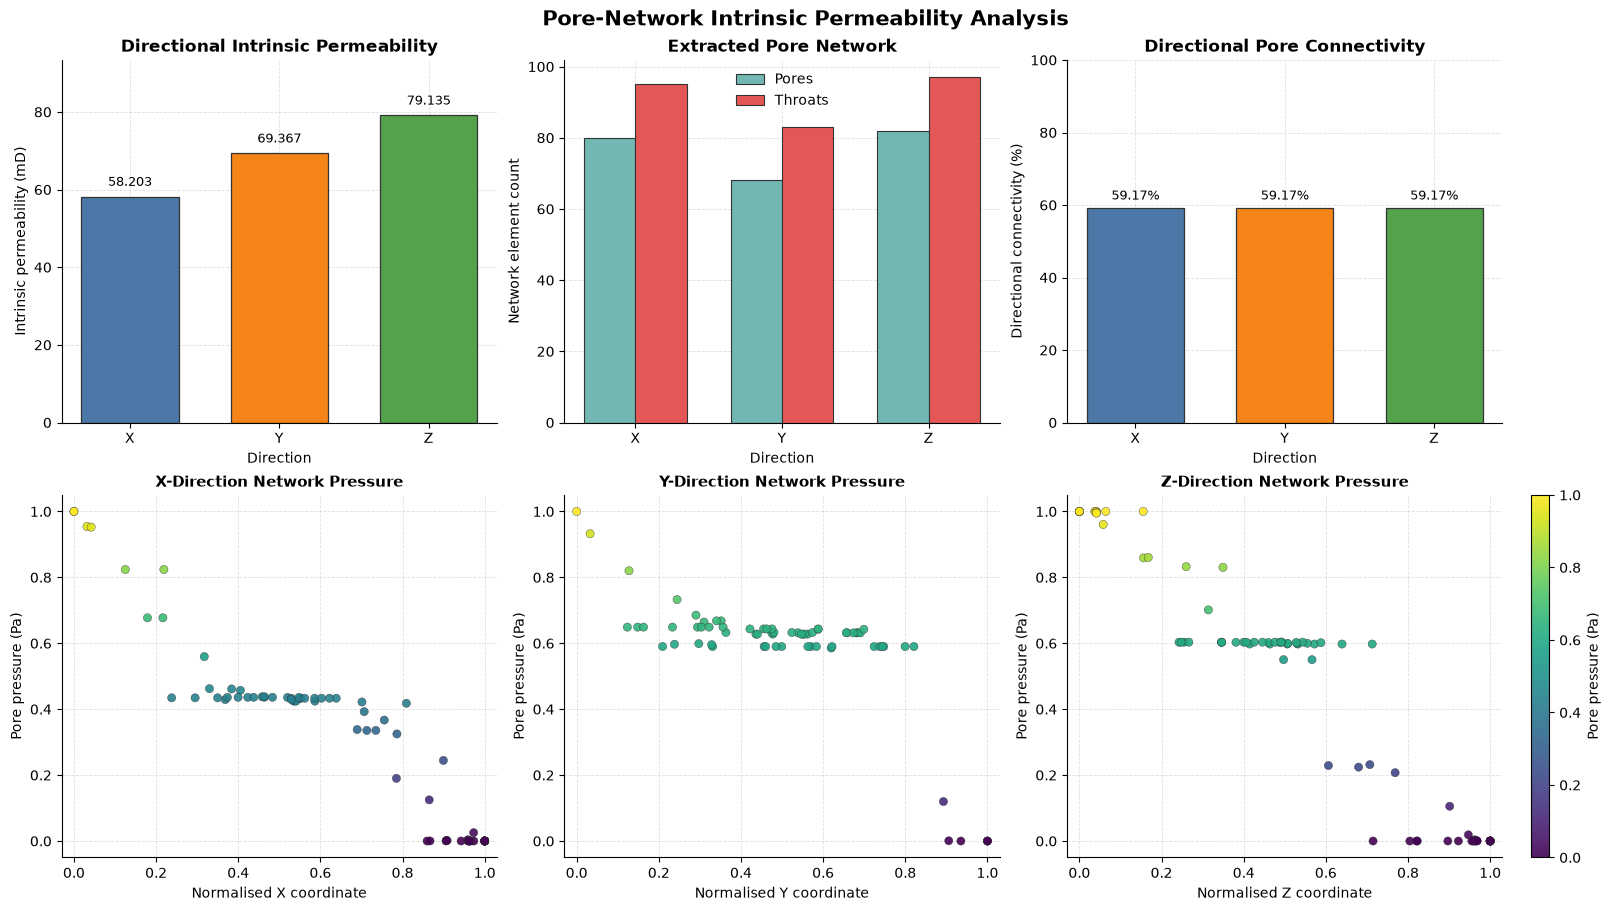

In [49]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Prepare summary data
# ============================================================

permeability_plot_summary = (
    permeability_xyz_summary
    .copy()
    .sort_values("Direction")
    .reset_index(drop=True)
)

directions = permeability_plot_summary[
    "Direction"
].astype(str).to_numpy()

permeability_md = permeability_plot_summary[
    "Intrinsic permeability (mD)"
].to_numpy(dtype=float)

network_pores = permeability_plot_summary[
    "Network pores"
].to_numpy(dtype=float)

network_throats = permeability_plot_summary[
    "Network throats"
].to_numpy(dtype=float)

directional_connectivity = permeability_plot_summary[
    "Directional connectivity (%)"
].to_numpy(dtype=float)

direction_colours = {
    "X": "#4C78A8",
    "Y": "#F58518",
    "Z": "#54A24B",
}

bar_colours = [
    direction_colours.get(direction, "#808080")
    for direction in directions
]


# ============================================================
# Create combined figure
# ============================================================

figure_permeability, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9),
    constrained_layout=True,
)


# ============================================================
# Panel 1: Intrinsic permeability
# ============================================================

bars_permeability = axes[0, 0].bar(
    directions,
    permeability_md,
    color=bar_colours,
    edgecolor="#333333",
    linewidth=0.9,
    width=0.65,
)

axes[0, 0].set_title(
    "Directional Intrinsic Permeability",
    fontsize=12,
    fontweight="bold",
)

axes[0, 0].set_xlabel("Direction")
axes[0, 0].set_ylabel(
    "Intrinsic permeability (mD)"
)

maximum_permeability = float(
    np.nanmax(permeability_md)
)

axes[0, 0].set_ylim(
    0,
    maximum_permeability * 1.18,
)

for bar, value in zip(
    bars_permeability,
    permeability_md,
):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height()
        + maximum_permeability * 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )


# ============================================================
# Panel 2: Network pores and throats
# ============================================================

x_positions = np.arange(
    len(directions)
)

bar_width = 0.35

axes[0, 1].bar(
    x_positions - bar_width / 2,
    network_pores,
    width=bar_width,
    color="#72B7B2",
    edgecolor="#333333",
    linewidth=0.8,
    label="Pores",
)

axes[0, 1].bar(
    x_positions + bar_width / 2,
    network_throats,
    width=bar_width,
    color="#E45756",
    edgecolor="#333333",
    linewidth=0.8,
    label="Throats",
)

axes[0, 1].set_xticks(
    x_positions,
    directions,
)

axes[0, 1].set_title(
    "Extracted Pore Network",
    fontsize=12,
    fontweight="bold",
)

axes[0, 1].set_xlabel("Direction")
axes[0, 1].set_ylabel("Network element count")

axes[0, 1].legend(
    frameon=False
)


# ============================================================
# Panel 3: Directional connectivity
# ============================================================

bars_connectivity = axes[0, 2].bar(
    directions,
    directional_connectivity,
    color=bar_colours,
    edgecolor="#333333",
    linewidth=0.9,
    width=0.65,
)

axes[0, 2].set_title(
    "Directional Pore Connectivity",
    fontsize=12,
    fontweight="bold",
)

axes[0, 2].set_xlabel("Direction")
axes[0, 2].set_ylabel(
    "Directional connectivity (%)"
)

maximum_connectivity = float(
    np.nanmax(directional_connectivity)
)

axes[0, 2].set_ylim(
    0,
    max(
        100,
        maximum_connectivity * 1.18,
    ),
)

for bar, value in zip(
    bars_connectivity,
    directional_connectivity,
):
    axes[0, 2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )


# ============================================================
# Bottom row: pore-network pressure distributions
# ============================================================

coordinate_axis = {
    "X": 0,
    "Y": 1,
    "Z": 2,
}

pressure_scatter = None

for axis, direction in zip(
    axes[1],
    ("X", "Y", "Z"),
):
    network = permeability_xyz_results[
        "networks"
    ][direction]

    pore_coordinates = np.asarray(
        network["pore.coords"],
        dtype=float,
    )

    pore_pressure = np.asarray(
        permeability_xyz_results[
            "pressure_fields"
        ][direction],
        dtype=float,
    )

    transport_coordinate = pore_coordinates[
        :,
        coordinate_axis[direction],
    ]

    coordinate_minimum = float(
        np.min(transport_coordinate)
    )

    coordinate_maximum = float(
        np.max(transport_coordinate)
    )

    coordinate_range = (
        coordinate_maximum
        - coordinate_minimum
    )

    if coordinate_range > 0:
        normalised_coordinate = (
            transport_coordinate
            - coordinate_minimum
        ) / coordinate_range
    else:
        normalised_coordinate = np.zeros_like(
            transport_coordinate
        )

    pressure_scatter = axis.scatter(
        normalised_coordinate,
        pore_pressure,
        c=pore_pressure,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        s=35,
        edgecolor="#333333",
        linewidth=0.3,
        alpha=0.9,
    )

    axis.set_title(
        f"{direction}-Direction Network Pressure",
        fontsize=11,
        fontweight="bold",
    )

    axis.set_xlabel(
        f"Normalised {direction} coordinate"
    )

    axis.set_ylabel(
        "Pore pressure (Pa)"
    )

    axis.set_xlim(
        -0.03,
        1.03,
    )

    axis.set_ylim(
        -0.05,
        1.05,
    )


# Shared pressure colour bar
pressure_colour_bar = (
    figure_permeability.colorbar(
        pressure_scatter,
        ax=axes[1, :].tolist(),
        orientation="vertical",
        fraction=0.025,
        pad=0.02,
    )
)

pressure_colour_bar.set_label(
    "Pore pressure (Pa)"
)


# ============================================================
# General formatting
# ============================================================

for axis in axes.flatten():
    axis.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.4,
    )

    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure_permeability.suptitle(
    "Pore-Network Intrinsic Permeability Analysis",
    fontsize=15,
    fontweight="bold",
)

plt.show()

In [50]:
import pandas as pd


def create_network_tables(
    network,
    pressure,
):
    pore_coordinates = np.asarray(
        network["pore.coords"],
        dtype=float,
    )

    pressure = np.asarray(
        pressure,
        dtype=float,
    )

    pore_count = pore_coordinates.shape[0]

    pore_data = {
        "pore_id": np.arange(
            pore_count,
            dtype=int,
        ),
        "coordinate_X": pore_coordinates[:, 0],
        "coordinate_Y": pore_coordinates[:, 1],
        "coordinate_Z": pore_coordinates[:, 2],
        "pressure_Pa": pressure,
    }

    pore_property_candidates = {
        "equivalent_diameter": (
            "pore.equivalent_diameter"
        ),
        "volume": "pore.volume",
        "surface_area": "pore.surface_area",
        "coordination_number": (
            "pore.coordination_number"
        ),
    }

    for output_name, network_key in (
        pore_property_candidates.items()
    ):
        if network_key in network:
            values = np.asarray(
                network[network_key]
            )

            if (
                values.ndim == 1
                and values.shape[0] == pore_count
            ):
                pore_data[output_name] = values

    pore_table = pd.DataFrame(
        pore_data
    )

    throat_connections = np.asarray(
        network["throat.conns"],
        dtype=int,
    )

    throat_count = (
        throat_connections.shape[0]
    )

    throat_data = {
        "throat_id": np.arange(
            throat_count,
            dtype=int,
        ),
        "connected_pore_1": (
            throat_connections[:, 0]
        ),
        "connected_pore_2": (
            throat_connections[:, 1]
        ),
    }

    throat_property_candidates = {
        "diameter": "throat.diameter",
        "equivalent_diameter": (
            "throat.equivalent_diameter"
        ),
        "total_length": (
            "throat.total_length"
        ),
        "direct_length": (
            "throat.direct_length"
        ),
        "cross_sectional_area": (
            "throat.cross_sectional_area"
        ),
    }

    for output_name, network_key in (
        throat_property_candidates.items()
    ):
        if network_key in network:
            values = np.asarray(
                network[network_key]
            )

            if (
                values.ndim == 1
                and values.shape[0] == throat_count
            ):
                throat_data[output_name] = values

    throat_table = pd.DataFrame(
        throat_data
    )

    return pore_table, throat_table

In [51]:
network_tables = {}

for direction in ("X", "Y", "Z"):
    network = permeability_xyz_results[
        "networks"
    ][direction]

    pressure = permeability_xyz_results[
        "pressure_fields"
    ][direction]

    pore_table, throat_table = (
        create_network_tables(
            network=network,
            pressure=pressure,
        )
    )

    network_tables[
        f"{direction} Pores"
    ] = pore_table

    network_tables[
        f"{direction} Throats"
    ] = throat_table

for table_name, table in (
    network_tables.items()
):
    print(
        table_name,
        table.shape,
    )

X Pores (80, 9)
X Throats (95, 8)
Y Pores (68, 9)
Y Throats (83, 8)
Z Pores (82, 9)
Z Throats (97, 8)


In [52]:
permeability_metadata = dict(
    permeability_xyz_results["metadata"]
)

permeability_metadata["analysis"] = (
    "Pore-network intrinsic permeability analysis"
)

permeability_tables = {
    "Permeability Summary": (
        permeability_xyz_summary
    ),
}

permeability_tables.update(
    network_tables
)

permeability_masks = {
    "through_connected_X": (
        permeability_xyz_results[
            "connectivity"
        ]["masks"]["through_connected_X"]
    ),
    "through_connected_Y": (
        permeability_xyz_results[
            "connectivity"
        ]["masks"]["through_connected_Y"]
    ),
    "through_connected_Z": (
        permeability_xyz_results[
            "connectivity"
        ]["masks"]["through_connected_Z"]
    ),
}

permeability_arrays = {}

for direction in ("X", "Y", "Z"):
    network = permeability_xyz_results[
        "networks"
    ][direction]

    permeability_arrays[
        f"{direction}_pore_coordinates"
    ] = np.asarray(
        network["pore.coords"]
    )

    permeability_arrays[
        f"{direction}_throat_connections"
    ] = np.asarray(
        network["throat.conns"]
    )

    permeability_arrays[
        f"{direction}_pore_pressure"
    ] = np.asarray(
        permeability_xyz_results[
            "pressure_fields"
        ][direction]
    )

In [53]:
permeability_exported_paths = (
    export_analysis_bundle(
        input_file=file_path,
        analysis_name="permeability",
        tables=permeability_tables,
        masks=permeability_masks,
        arrays=permeability_arrays,
        metadata=permeability_metadata,
        figure=figure_permeability,
    )
)

permeability_exported_paths

{'output_directory': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results'),
 'binary_masks': {'through_connected_X': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_permeability_through_connected_X.tif'),
  'through_connected_Y': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_permeability_through_connected_Y.tif'),
  'through_connected_Z': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_permeability_through_connected_Z.tif')},
 'scalar_volumes': {},
 'excel': WindowsPath('C:/Users/zixia/XseeO2_coding_folder/synthetic_labelled_cement_4phase_100_cemct_results/synthetic_labelled_cement_4phase_100_permeability_results.xlsx'),
 'metadata_json': WindowsPath('C:/Users/zixia/XseeO2_c

In [54]:
print_exported_paths(
    permeability_exported_paths
)

output_directory: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results [exists=True]
binary_masks:
    through_connected_X: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_permeability_through_connected_X.tif [exists=True]
    through_connected_Y: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_permeability_through_connected_Y.tif [exists=True]
    through_connected_Z: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_permeability_through_connected_Z.tif [exists=True]
scalar_volumes:
excel: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4phase_100_cemct_results\synthetic_labelled_cement_4phase_100_permeability_results.xlsx [exists=True]
metadata_json: C:\Users\zixia\XseeO2_coding_folder\synthetic_labelled_cement_4ph